In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [5]:
# How do Sales, Profit, and Order Volume distribute across different customer Segments (Consumer, Corporate, Home Office)?

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [7]:
#segment, sales, profit, count of orders
segment_dist_sales_profit_orders = df.groupby(df['Segment'])[['Sales','Profit','Order ID']].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum'),
    number_of_orders = ('Order ID','count')
).round(2)
segment_dist_sales_profit_orders

,total_sales,total_profit,number_of_orders
Segment,,,
Consumer,6406418.75,741637.20,26039
Corporate,3743038.15,431124.37,15118
Home Office,2271526.94,270036.56,9184
Unknown,244272.91,27797.42,1029


In [8]:
segment_dist_sales_profit_orders.reset_index(inplace=True)
segment_dist_sales_profit_orders

,Segment,total_sales,total_profit,number_of_orders
0,Consumer,6406418.75,741637.20,26039
1,Corporate,3743038.15,431124.37,15118
2,Home Office,2271526.94,270036.56,9184
3,Unknown,244272.91,27797.42,1029


In [9]:
# How do Sales, Profit, and Order Volume distribute across different customer Segments (Consumer, Corporate, Home Office)

In [10]:
segment_dist_sales_profit_orders = segment_dist_sales_profit_orders[segment_dist_sales_profit_orders['Segment'] != 'Unknown']
segment_dist_sales_profit_orders

,Segment,total_sales,total_profit,number_of_orders
0,Consumer,6406418.75,741637.20,26039
1,Corporate,3743038.15,431124.37,15118
2,Home Office,2271526.94,270036.56,9184


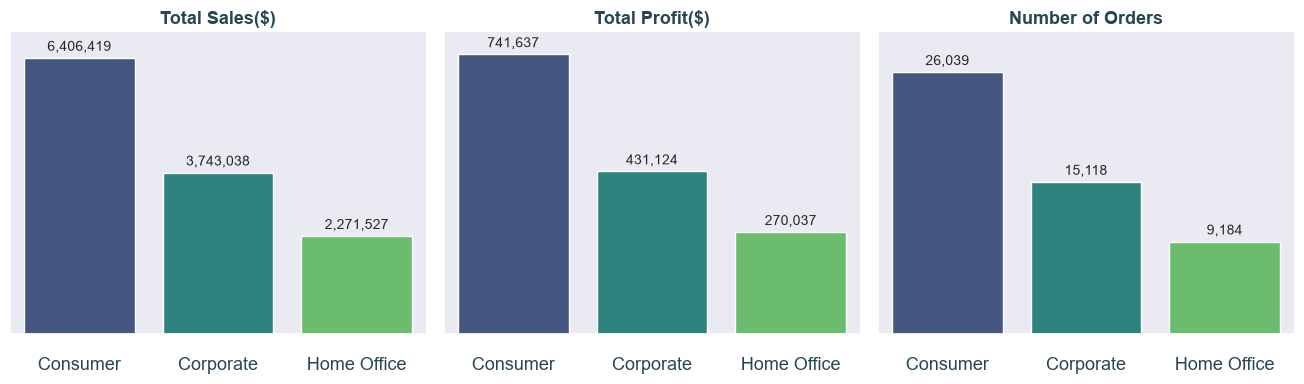

In [52]:
sns.set_theme()
# reshape wide -> long
df_long = segment_dist_sales_profit_orders.melt(
    id_vars='Segment',
    value_vars=['total_sales', 'total_profit', 'number_of_orders'],
    var_name='measure',
    value_name='value'
)

g = sns.catplot(
    data=df_long,
    x='Segment',
    y='value',
    col='measure',
    hue='Segment',
    kind='bar',
    sharey=False,       # each measure gets its own y-scale
    height=4,
    aspect=1.1,
    palette='viridis'
)
g.set_titles('{col_name}') # cleaner facet titles

# ================== x-axis ================== 
g.set_xlabels('')
g.set_xticklabels(fontsize=13)

# ================== y-axis ================== 
g.set_ylabels('')
g.set_yticklabels([])
g.tick_params(size=13, labelcolor='#264653')

subplot_titles = ["Total Sales($)","Total Profit($)","Number of Orders"]
for ax, title in zip(g.axes.flat, subplot_titles):
    ax.tick_params(axis='x')
    ax.grid(False)
    ax.set_title(title, fontsize=13, fontweight='bold', color='#264653')

    # add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

In [53]:
# Business Question 8:
# How do Sales, Profit, and Order Volume distribute across different customer Segments (Consumer, Corporate, Home Office)

# Answer:
# Each Chart tells the same thing, Consumer segment holds the top by each measure, either in sales, profit, or total transaction made whilst Home Office
# takes the bottom, it still yields better performance nonetheless with a profit amounting around $270k.